In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [22]:
class QuadState(TypedDict):
    a : int
    b : int
    c : int
    D : int
    result : str
    equation : str

In [ ]:
def show_equation(state : QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    equation = f"{a}x2 + ({b}x) + ({c})"
    
    return {"equation":equation}   

def find_discriminant(state : QuadState):
    a = state['a']
    b = state['b']
    c = state['c']
    
    D = b**2 - 4*a*c
    
    return {'D':D}

def find_real_roots(state : QuadState):
    a = state['a']
    b = state['b']
    D = state['D']
    
    root1 = (-b + (D**0.5))/2*a
    root2 = (-b - (D**0.5))/2*a
    
    return {'result':f"The roots are {root1} and {root2}"}

def find_repeated_roots(state : QuadState):
    root = -state['b']/(2*state['a'])
    
    return {'result':f"The only root is {root}"}

def return_no_roots(state : QuadState):
    
    return {'result':"No real roots"}


# Routing Function gives the names of upcoming nodes as output
def check_condition(state : QuadState) -> Literal['real_roots','repeated_roots','no_roots']:
    
    if state['D'] > 0:
        return 'real_roots'
    elif state['D'] == 0:
        return 'repeated_roots'
    else:
        return 'no_roots'

In [24]:
graph = StateGraph(QuadState)

graph.add_node("show_equation",show_equation)
graph.add_node("find_discriminant",find_discriminant)
graph.add_node("real_roots",find_real_roots)
graph.add_node("repeated_roots",find_repeated_roots)
graph.add_node("no_roots",return_no_roots)


graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","find_discriminant")

# Conditional Edge
graph.add_conditional_edges("find_discriminant",check_condition)

graph.add_edge("real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("no_roots",END)

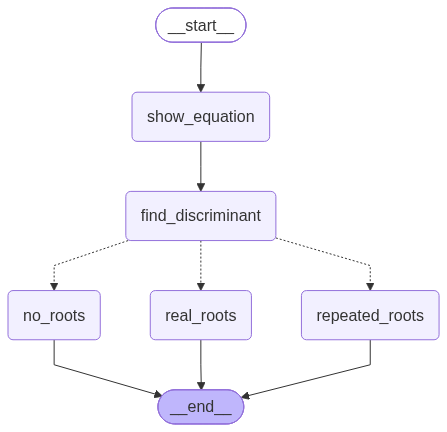

In [25]:
workflow = graph.compile()
workflow

In [ ]:
initial_state = {
    'a' : 3,
    'b' : 4,
    'c' : 2
}

workflow.invoke(initial_state)